# Testing the EDR and EFD Calculations

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np


from contigo.constellation import Constellation
from contigo.edr_efd import EDRDensity

from contigo.forces.third_body_acc import ThirdBody
from contigo.forces.grav_pot import EarthPotential

In [20]:
sw_e = pd.read_hdf("./data/ESA_pod.hdf")
sw_o = pd.read_hdf("./data/ore_d.hdf")

print(sw_e.columns)
print(sw_o.columns)

Index(['index', 'sat', 'x', 'y', 'z', 'DateTime', 'vx', 'vy', 'vz',
       'EstSat.EarthFixed.X', 'EstSat.EarthFixed.Y', 'EstSat.EarthFixed.Z',
       'EstSat.EarthFixed.VX', 'EstSat.EarthFixed.VY', 'EstSat.EarthFixed.VZ',
       'EstSat.TAIGregorian', 'eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy',
       'eci_vz', 'eg_x', 'eg_y', 'eg_z', 'sg_x', 'sg_y', 'sg_z', 'mg_x',
       'mg_y', 'mg_z', 'srp_x', 'srp_y', 'srp_z'],
      dtype='str')
Index(['eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy', 'eci_vz', 'eci_sn_ax',
       'eci_sn_ay', 'eci_sn_az', 'eci_mn_ax', 'eci_mn_ay', 'eci_mn_az',
       'ecef_sn_ax', 'ecef_sn_ay', 'ecef_sn_az', 'ecef_mn_ax', 'ecef_mn_ay',
       'ecef_mn_az', 'ecef_sn_px', 'ecef_sn_py', 'ecef_sn_pz', 'ecef_mn_px',
       'ecef_mn_py', 'ecef_mn_pz', 'earth_gp', 'DateTime', 'ecef_x', 'ecef_y',
       'ecef_z', 'ecef_vx,', 'ecef_vy', 'ecef_vz', 'edr', 'denom'],
      dtype='str')


In [4]:
# create a Constellation object from the ESA POD file
# and calculate thirdbody acceleration from ThirdBody
hdf_sc = Constellation(state_file=r'D:\GitHub\contigo_edr\data\ESA_pod.hdf', 
                    time_col='DateTime', x_col='x', y_col='y', z_col='z',
                    vx_col='vx', vy_col='vy', vz_col='vz', 
                    sc_id_col='filename', sc_fn_slc=slice(-11,-8),
                    tscale_input='GPS')

In [5]:
ep = EarthPotential()
tba = ThirdBody(body=['SUN','MOON'])

In [6]:
edr = EDRDensity(sc_system=hdf_sc,force_models=[tba],potential_model=ep)

In [15]:
acc_con = edr.compute_edr()

INFO:Loading Potential coeffecients from current state which used EIGEN-2.gfc.
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


In [16]:
contigo = pd.DataFrame(acc_con['ESA'])

True


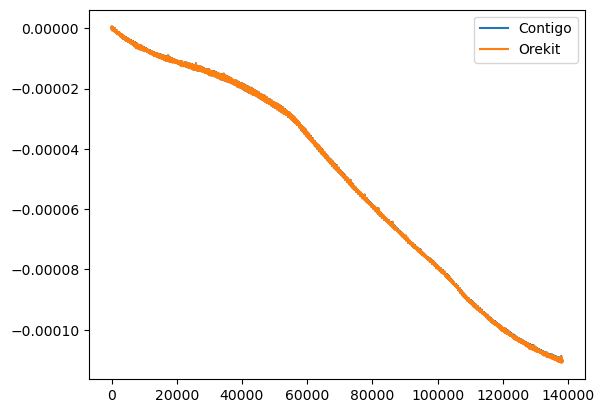

In [22]:
sw_o['edr_km'] = (sw_o['edr']-sw_o['edr'][0])/(1000**2)
ax = contigo['edr'].plot(label='Contigo')
sw_o['edr_km'].plot(ax=ax,label='Orekit')

ax.legend()

ac = np.allclose(sw_o['edr_km'].to_numpy(),contigo['edr'].to_numpy(),atol=1E-7,rtol=0.01)
print(ac)


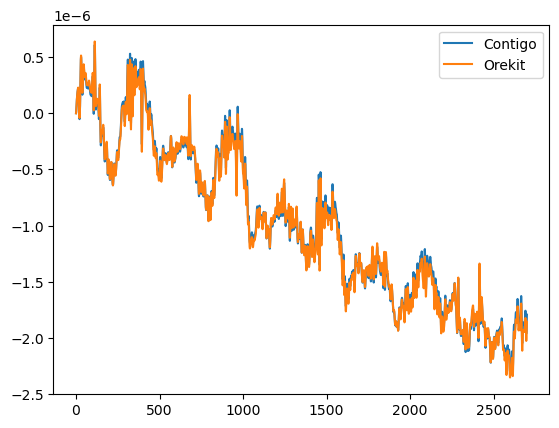

In [24]:
end = int(5*90*60/10)
ax = contigo['edr'][0:end].plot(label='Contigo')
sw_o['edr_km'][0:end].plot(ax=ax, label='Orekit')
ax.legend()
